Dataset shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


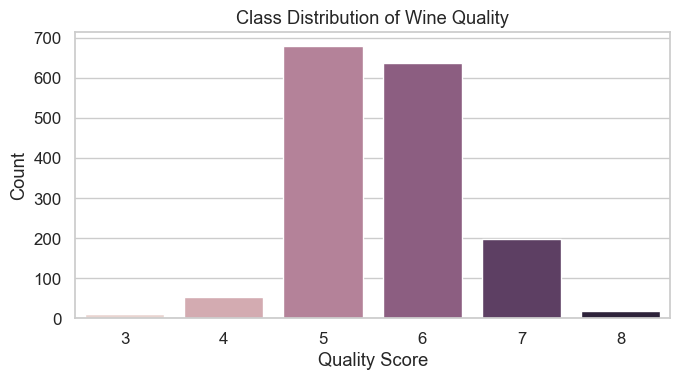


=== Feature stats (with skewness + IQR outliers) ===
                           mean        std      min      25%       50%  \
chlorides              0.087467   0.047065  0.01200   0.0700   0.07900   
residual sugar         2.538806   1.409928  0.90000   1.9000   2.20000   
sulphates              0.658149   0.169507  0.33000   0.5500   0.62000   
total sulfur dioxide  46.467792  32.895324  6.00000  22.0000  38.00000   
free sulfur dioxide   15.874922  10.460157  1.00000   7.0000  14.00000   
fixed acidity          8.319637   1.741096  4.60000   7.1000   7.90000   
alcohol               10.422983   1.065668  8.40000   9.5000  10.20000   
volatile acidity       0.527821   0.179060  0.12000   0.3900   0.52000   
citric acid            0.270976   0.194801  0.00000   0.0900   0.26000   
pH                     3.311113   0.154386  2.74000   3.2100   3.31000   
density                0.996747   0.001887  0.99007   0.9956   0.99675   

                            75%        max      skew   ku

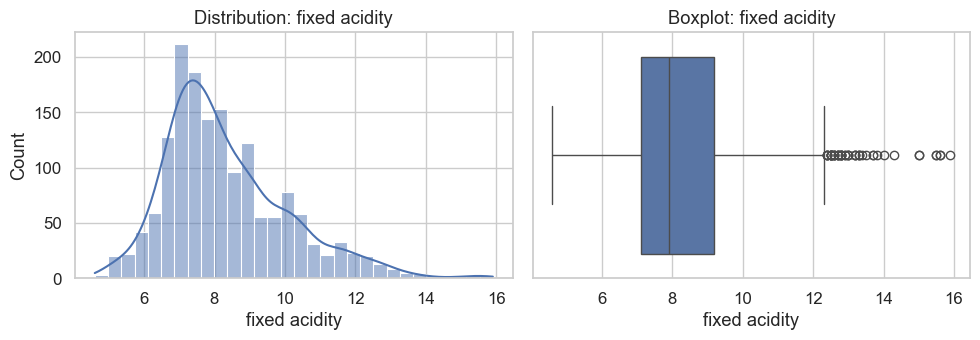

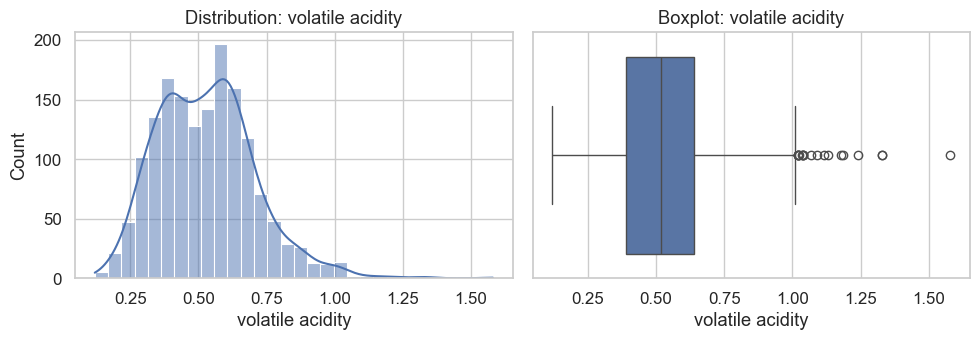

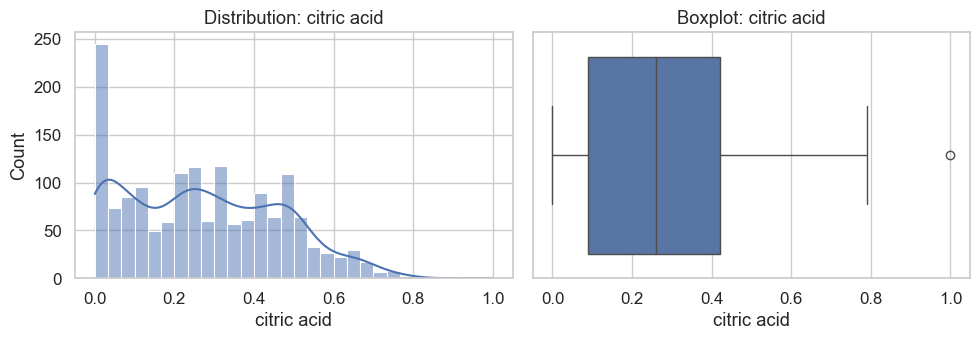

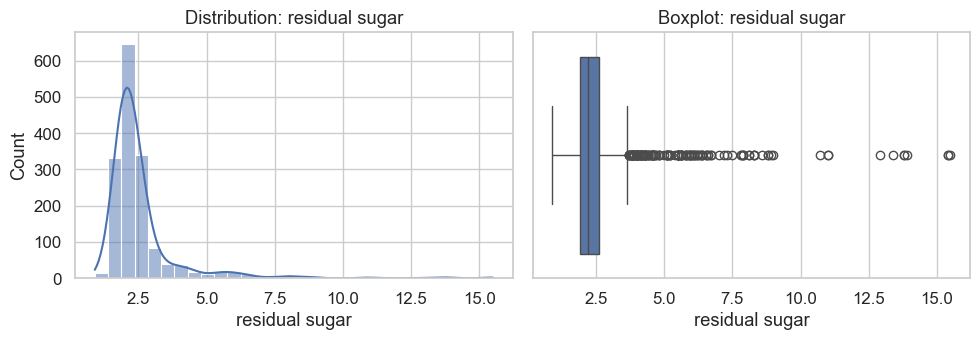

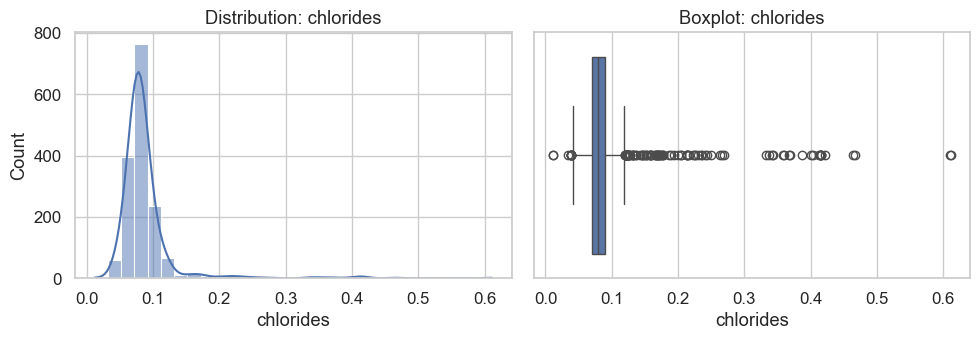

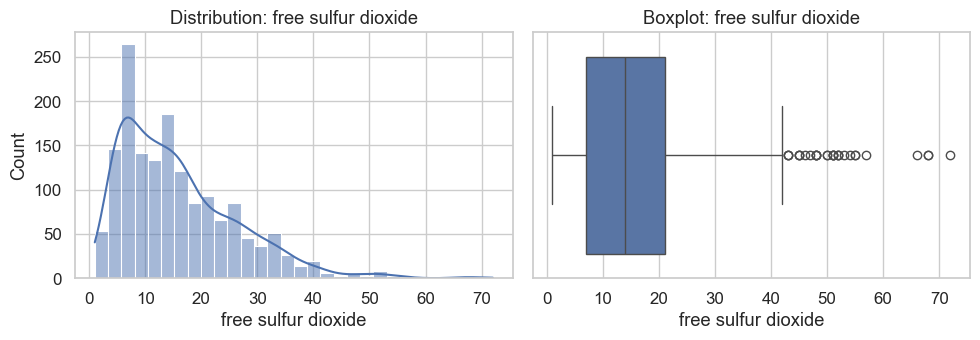

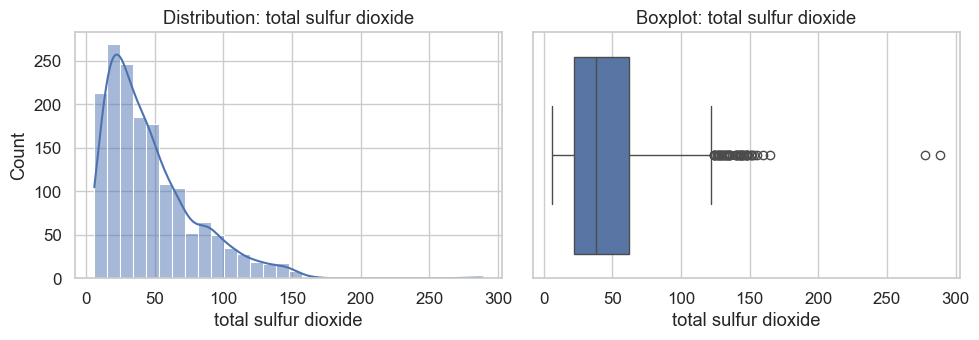

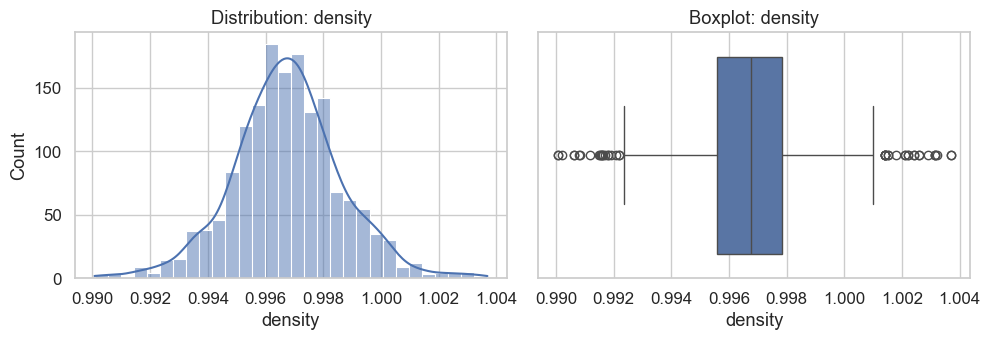

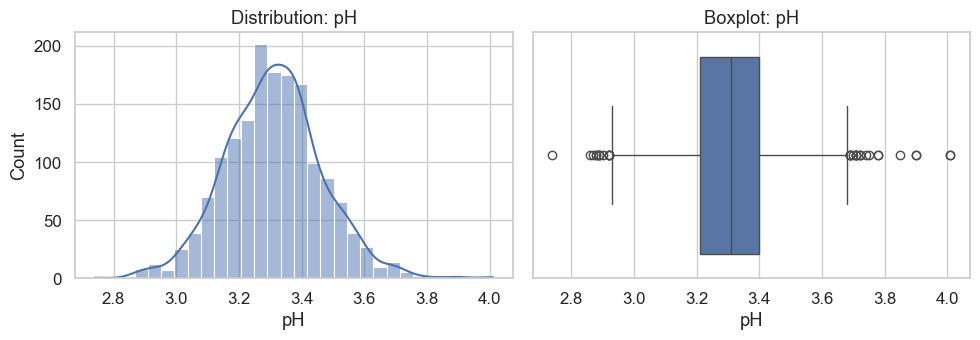

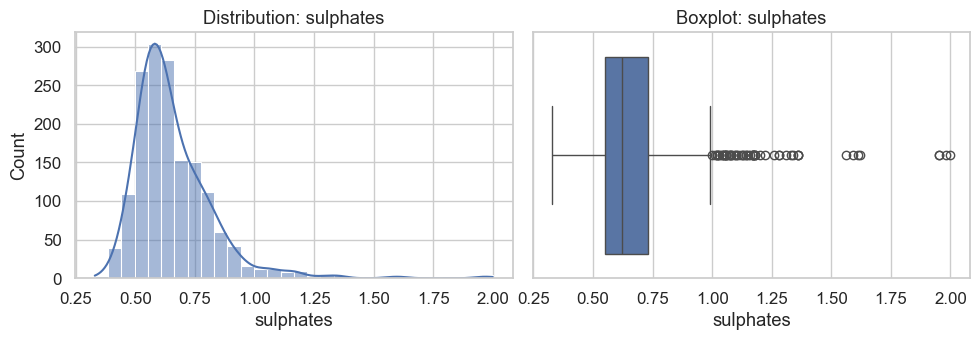

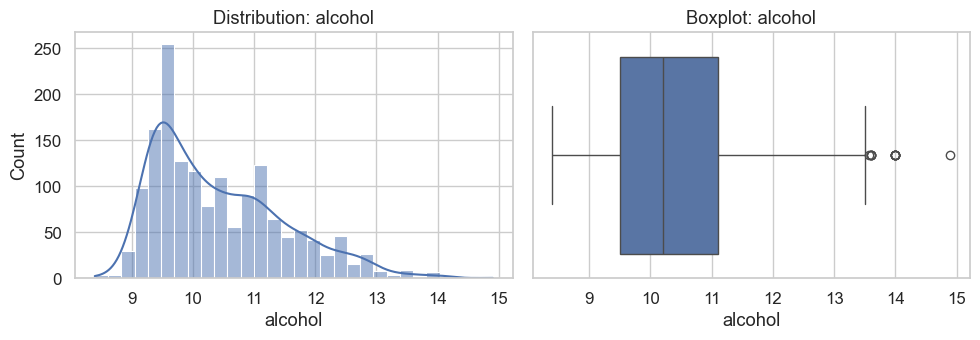

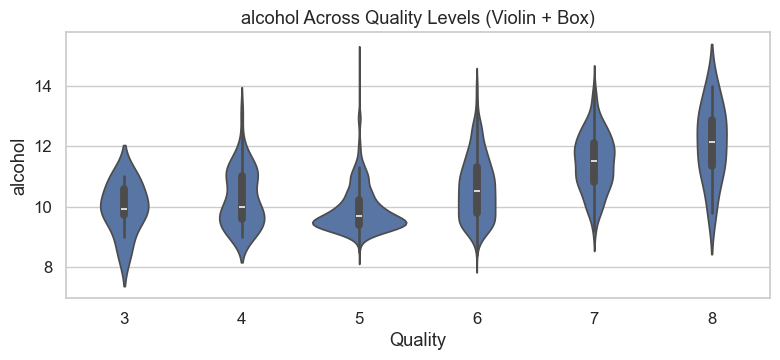

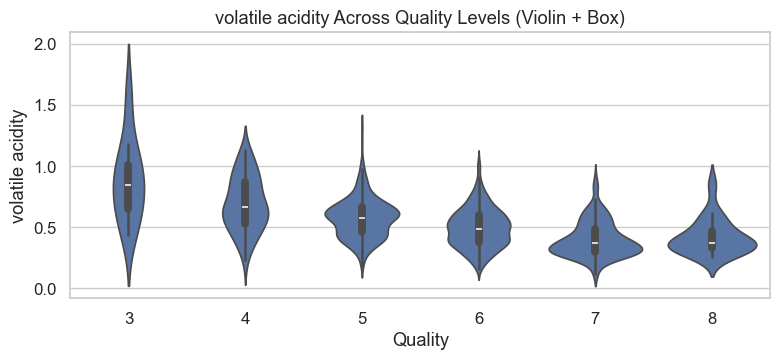

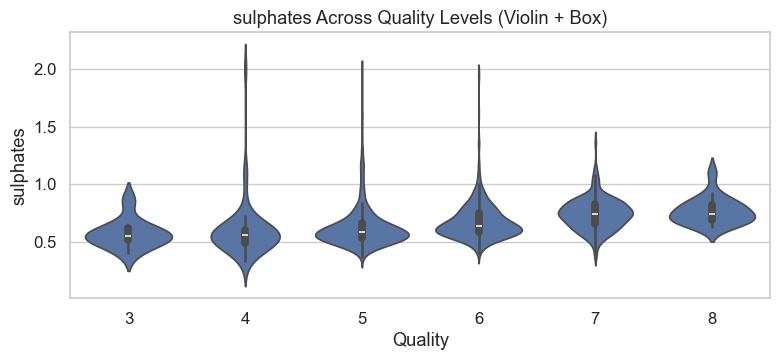

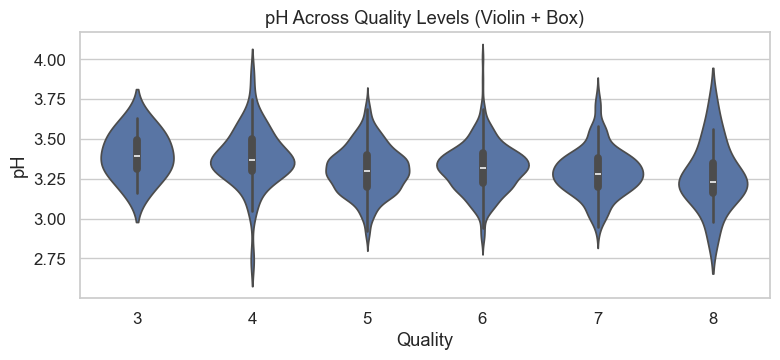

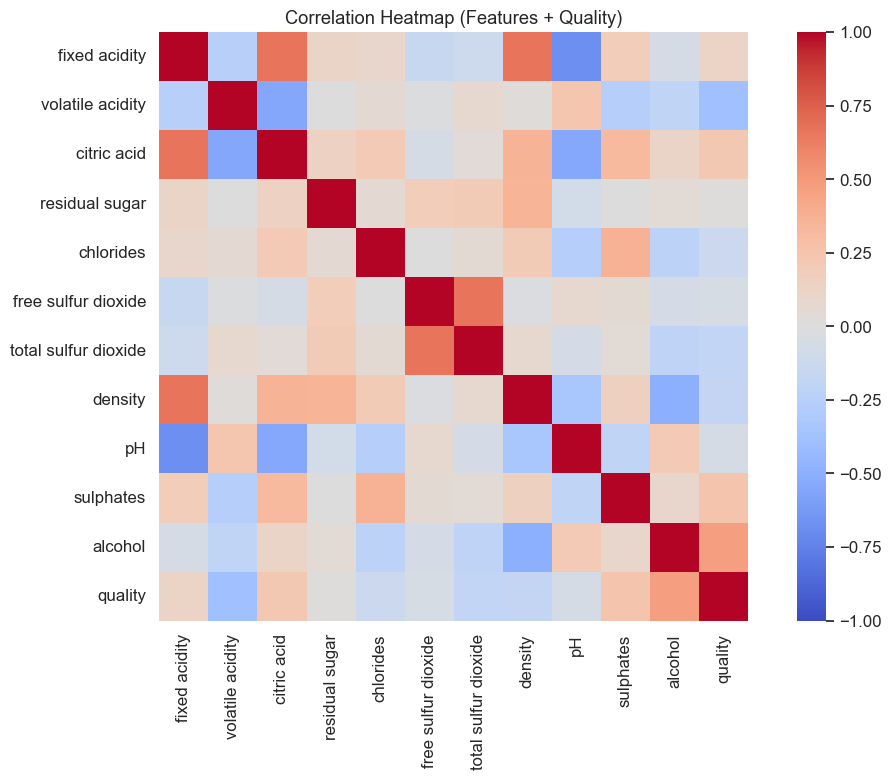

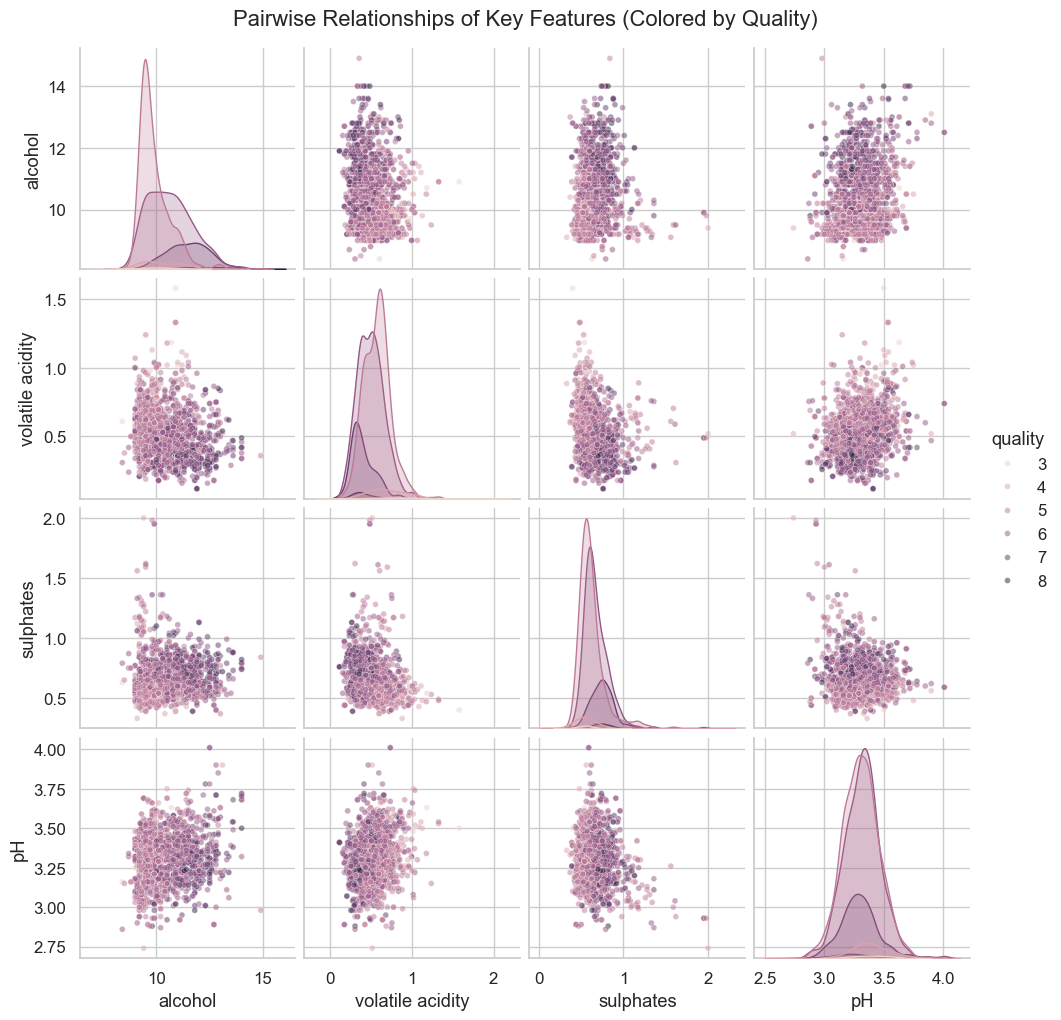


PCA 2D explained variance ratio (PC1, PC2): [0.28173931 0.1750827 ]


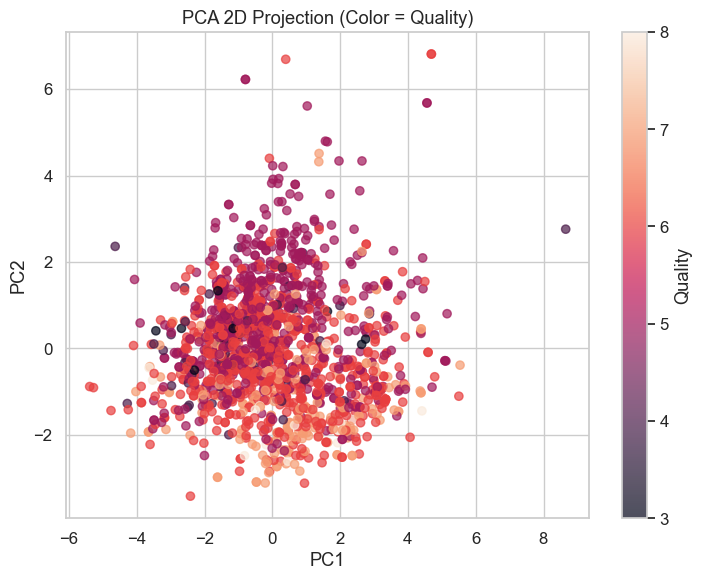

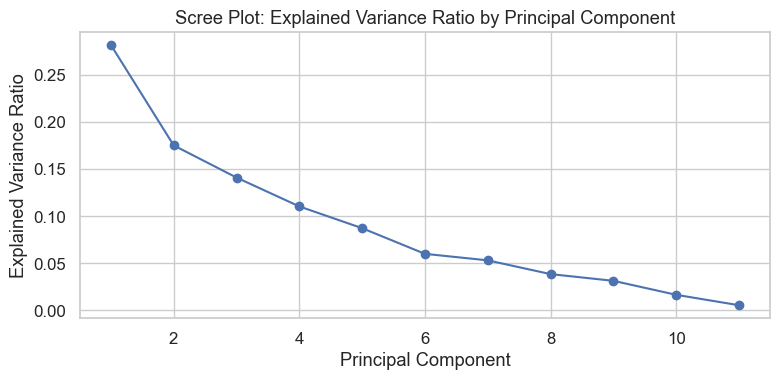

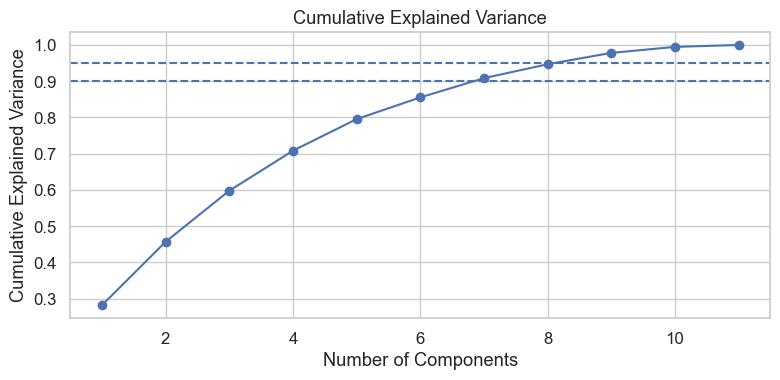


#PCs needed for >=90% variance: 7
#PCs needed for >=95% variance: 9

 Module X (EDA) completed: distributions, boxplots, skew/outliers, correlation, PCA.


In [1]:
# ============================================
# Module X  Data Visualization & Feature Insights
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# 0) Global settings
# ----------------------------
sns.set(style="whitegrid", font_scale=1.1)

# Optional: save figures for report
SAVE_FIGS = False
FIG_DIR = "figs_eda"
if SAVE_FIGS:
    os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name: str):
    if SAVE_FIGS:
        plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches="tight")

# ----------------------------
# 1) Load dataset
# ----------------------------
# Change path if needed
DATA_PATH = "winequality-red.csv"

df = pd.read_csv("/Users/ritawang/Desktop/learning/ESE 4170/Final/data/KNN/winequality-red_sep.csv")
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

# Split features/label
y = df["quality"]
X = df.drop(columns=["quality"])

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nQuality distribution:")
print(y.value_counts().sort_index())

# ----------------------------
# 2) Target distribution plot
# ----------------------------
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="quality", hue="quality", legend=False)
plt.title("Class Distribution of Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
savefig("01_quality_distribution.png")
plt.show()

# ----------------------------
# 3) Summary statistics + skewness + outlier counts
# ----------------------------
desc = X.describe().T
desc["skew"] = X.skew(numeric_only=True)
desc["kurtosis"] = X.kurtosis(numeric_only=True)

# IQR outlier count per feature
outlier_counts = {}
for col in X.columns:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    outlier_counts[col] = int(((X[col] < lo) | (X[col] > hi)).sum())

desc["iqr_outliers"] = pd.Series(outlier_counts)

print("\n=== Feature stats (with skewness + IQR outliers) ===")
print(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis", "iqr_outliers"]]
      .sort_values("skew", ascending=False))

# ----------------------------
# 4) Univariate distributions + boxplots (core requirement)
# ----------------------------
# Make it easy for report: one feature per figure, with histogram+kde and boxplot side-by-side.
features = list(X.columns)

for col in features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

    # Histogram + KDE
    sns.histplot(X[col], kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f"Distribution: {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(x=X[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    savefig(f"dist_box_{col.replace(' ', '_')}.png")
    plt.show()

# ----------------------------
# 5) Feature vs Quality (violin/box style)
# ----------------------------
# This helps show how each feature shifts across quality levels.
key_features = ["alcohol", "volatile acidity", "sulphates", "pH"]
for col in key_features:
    plt.figure(figsize=(8, 3.8))
    sns.violinplot(data=df, x="quality", y=col, inner="box")
    plt.title(f"{col} Across Quality Levels (Violin + Box)")
    plt.xlabel("Quality")
    plt.ylabel(col)
    plt.tight_layout()
    savefig(f"violin_{col.replace(' ', '_')}_by_quality.png")
    plt.show()

# ----------------------------
# 6) Correlation heatmap
# ----------------------------
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap (Features + Quality)")
plt.tight_layout()
savefig("02_correlation_heatmap.png")
plt.show()

# ----------------------------
# 7) Pairplot (optional but good for report)
# ----------------------------
pair_cols = key_features + ["quality"]
sns.pairplot(df[pair_cols], hue="quality", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 18})
plt.suptitle("Pairwise Relationships of Key Features (Colored by Quality)", y=1.02)
savefig("03_pairplot_key_features.png")
plt.show()

# ----------------------------
# 8) PCA visualization (2D) + explained variance analysis
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# (a) PCA 2D projection
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print("\nPCA 2D explained variance ratio (PC1, PC2):", pca2.explained_variance_ratio_)

plt.figure(figsize=(7.5, 6))
sc = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, alpha=0.7)
plt.colorbar(sc, label="Quality")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection (Color = Quality)")
plt.tight_layout()
savefig("04_pca2_scatter.png")
plt.show()

# (b) Scree plot + cumulative explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.title("Scree Plot: Explained Variance Ratio by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.tight_layout()
savefig("05_scree_plot.png")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
savefig("06_cumulative_explained_variance.png")
plt.show()

# Print how many PCs to reach 90% / 95%
k90 = int(np.argmax(cum_explained >= 0.90) + 1)
k95 = int(np.argmax(cum_explained >= 0.95) + 1)
print(f"\n#PCs needed for >=90% variance: {k90}")
print(f"#PCs needed for >=95% variance: {k95}")

print("\n Module X (EDA) completed: distributions, boxplots, skew/outliers, correlation, PCA.")
